In [14]:
RR(pi)

3.1415926535897932384626433833

In [9]:
import sys
sys.path.append("/home/macbuse/miniconda3/lib/python3.11/site-packages")

# Roger's L function の実装
import numpy as np
from scipy.special import spence

RR=RealField(200)

def rogers_l_function(x):
#def rr(x):
	"""
	Rogers L-function (L(x)) implementation.

	Parameters:
	    x (float): Input value (0 < x < 1).

	Returns:
	    float: Value of L(x).
	"""
	# if x <= 0 or x >= 1:
	#     raise ValueError("x must be in the range (0, 1)")
	#yo:型をPython floatに変換
	x = float(x)
	dilog = spence(1 - x)  # spence(z) computes -Li2(1-z), so spence(1-x) = -Li2(x)
	log_term = 0.5 * np.log(x) * np.log(1 - x)
	return dilog + log_term

# 使用例
x = 0.5
print("Rogers L-function L(0.5):", rogers_l_function(x))
# 知られている結果を合わせて実験
import math
from decimal import Decimal, getcontext


#hm:このclass はおそらく必要なくなってしまったので、使わないほうが読みやすいコードになりそうです。。。→済
#（最初に変なことを言った記憶があります、めんどうかけてすみません）
def main(n,xL,yL,zL):
	# 初期値設定
	len12=RR(((xL*yL+zL)*zL+(xL*zL+yL)*yL+(xL)**2+(yL)**2+(zL)**2+2*xL*yL*zL-1)/((xL)**2-1))
	if n==1:
		result_dic={QQ(0)/QQ(1):yL,QQ(1)/QQ(1):zL,QQ(1)/QQ(2):len12}
		return result_dic
	#result={xyzリスト:[LR,[B,C,A2,A1],frac,endpoint]}
	result={'xy': ['L',[[0,1],[1,2],[1,1],[1,3]],QQ(1)/QQ(3),endpoint('xy')], 'xz': ['R', [[1,1],[1,2],[0,1],[2,3]],QQ(2)/QQ(3),endpoint('xz')], 'xyx': ['LL',[[0,1],[1,3],[1,2],[1,4]],QQ(1)/QQ(4),endpoint('xyx')], 'xyz': ['LR',[[1,2],[1,3],[0,1],[2,5]],QQ(2)/QQ(5),endpoint('xyz')], 'xzx': ['RR',[[1,1],[2,3],[1,2],[3,4]],QQ(3)/QQ(4),endpoint('xzx')], 'xzy': ['RL',[[1,2],[2,3],[1,1],[3,5]],QQ(3)/QQ(5),endpoint('xzy')]}
	#resultLen={frac:length}
	resultLen={QQ(0)/QQ(1):[yL,'Z'],QQ(1)/QQ(1):[zL,'Y'], QQ(1)/QQ(2):[len12,'X'],QQ(1)/QQ(3):[edge_relation(yL,zL,xL,yL,len12,zL),endpoint('xy')],QQ(2)/QQ(3):[edge_relation(zL,yL,xL,zL,len12,yL),endpoint('xz')]}
	resultLen[QQ(1)/QQ(4)]=[edge_relation(xL,zL,yL,yL,resultLen[QQ(1)/QQ(3)][0],len12),endpoint('xyx')]
	resultLen[QQ(2)/QQ(5)]=[edge_relation(zL,xL,yL,len12,resultLen[QQ(1)/QQ(3)][0],yL),endpoint('xyz')]
	resultLen[QQ(3)/QQ(4)]=[edge_relation(xL,yL,zL,zL,resultLen[QQ(2)/QQ(3)][0],len12),endpoint('xzx')]
	resultLen[QQ(3)/QQ(5)]=[edge_relation(yL,xL,zL,len12,resultLen[QQ(2)/QQ(3)][0],zL),endpoint('xzy')]

	#長さがdepthのxyzの文字列を全て列挙する
	xyzList=["xy","xz"]
	#hm: len(result[0])<n:をlen(result[-1])<n:に変えて→済
	while len(xyzList[-1])<n:
		newxyz=[]
		for i in xyzList:
		  for char in "xyz":
		      # 直前の文字と異なる場合にのみ追加
		      if i[-1] != char:
		          newxyz.append(i + char)
		#hm: 以下を result+=newresult にすればOK（=が+=に）→済
		xyzList+=newxyz
	
	for s in xyzList:
		if s in result:
		  continue
		# xyzの最後から2つ前と一番最後が同じなら、前のLorRと同じものを付け加える、Bは前と同じB、A2は前のC
		if s[-3]==s[-1]:
		  resultLR=result[s[:-1]][0] + result[s[:-1]][0][-1]
		  fracB=result[s[:-1]][1][0]
		  fracA2=result[s[:-1]][1][1]
		# xyzの最後から2つ前と一番最後が違うなら、前のLorRと違うものを付け加える、Bは前のC、A2は前のB
		else:
		  resultLR = result[s[:-1]][0] + ('R' if result[s[:-1]][0][-1] == 'L' else 'L')
		  fracB=result[s[:-1]][1][1]
		  fracA2=result[s[:-1]][1][0]
		fracC=result[s[:-1]][1][3]
		frac=QQ(fracB[0]+fracC[0])/QQ(fracB[1]+fracC[1])
		result[s]=[resultLR,[fracB,fracC,fracA2,[fracB[0]+fracC[0], fracB[1]+fracC[1]]],frac, endpoint(s)]
		resultLen[frac]=[edge_relation(return_len(s[-1],xL,yL,zL),return_len([item for item in ['x','y','z'] if item not in [s[-1],s[-2]]][0],xL,yL,zL),return_len(s[-2],xL,yL,zL),resultLen[QQ(fracB[0])/QQ(fracB[1])][0],resultLen[QQ(fracC[0])/QQ(fracC[1])][0],resultLen[QQ(fracA2[0])/QQ(fracA2[1])][0]), endpoint(s)]
	return resultLen

def return_len(s, xL, yL, zL):
    return {"x": xL, "y": yL, "z": zL}[s]
    
def edge_relation(aL,bL,cL,B,C,A):
	return RR((2*(aL*bL+cL)*B)/(aL**2-1)+(2*(aL*cL+bL)*C)/(aL**2-1)-A)

# in:xyzのリスト out:end point
# end point・・・xの向かい側：a, yの向かい側：b, zの向かい側：c
def endpoint(s):
    return {"x": "X", "y": "Y", "z": "Z"}[s[-1]]



def get_boundary_length(a,b,c):
	dd = main(1,a,b,c)
	x = dd[QQ(1)/QQ(2)]
	Y = dd[QQ(0)/QQ(1)]
	Z = dd[QQ(1)/QQ(1)]

	numer = RR(x+Y*Z)
	denom = RR(sqrt((Y**2-1)*(Z**2-1)))
	return acosh(numer/denom)
get_boundary_length(1.2,1.2,1.2)


farey = []
Sum = 0

a = RR(3)
b= a
c = a


def Bridgeman_prob(Len,depth=10):
    ### Bridgeman idendity #####
    a = RR(Len)
    b = a
    c = a
    DD=[main(depth,a,b,c)] #, main(depth,b,c,a), main(depth,c,a,b)]
    sumX = 0
    sumY = 0
    sumZ = 0
    for dd in DD[::-1]:
        #print(dd.length())
        for ll in dd.values():
        	if ll[1]=='X':
        		lll = (ll[0]+1)/2
        		sumX+=rogers_l_function(1/lll)
        	if ll[1]=='Y':
        		lll = (ll[0]+1)/2
        		sumY+=rogers_l_function(1/lll)
        	if ll[1]=='Z':
        		lll = (ll[0]+1)/2
        		sumZ+=rogers_l_function(1/lll)
    sumX = sumX 
    sumYZ = sumY+sumZ-(rogers_l_function(1/((a+1)/2)))
    
    # Sum と math.pi**2/6 はほぼ同じ値、Sum-math.pi**2/6 は負の値であるはず
    #print(sumX,sumYZ,sumX+sumYZ, RR(pi)**2/6, sumX+sumYZ-RR(pi)**2/6)
    return sumX/(sumX+sumYZ)


Bridgeman_prob(3)

/tmp/ipykernel_11717/2675075172.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.special import spence


NameError: name 'RealField' is not defined

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 定義域
x = np.linspace(1.001, 15, 100)

# 関数定義
y = []
for a in x:
    y.append(Bridgeman_prob(a,10))

# グラフ描画
plt.figure(figsize=(8, 4))
plt.plot(x, y)
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.title("probability of returning back")
#plt.xlabel("x")
#plt.ylabel("f(x)")
plt.grid(True)
#plt.legend()
plt.show()

NameError: name 'Bridgeman_prob' is not defined

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 定義域
x = np.linspace(1.001, 15, 100)

# 関数定義
y = []
for a in x:
    y.append(Bridgeman_prob(a,11))

# グラフ描画
plt.figure(figsize=(8, 4))
plt.plot(x, y)
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.title("probability of returning back")
#plt.xlabel("x")
#plt.ylabel("f(x)")
plt.grid(True)
#plt.legend()
plt.show()

NameError: name 'Bridgeman_prob' is not defined

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 定義域
x = np.linspace(1.001, 15, 100)

# 関数定義
y = []
for a in x:
    y.append(Bridgeman_prob(a,12))

# グラフ描画
plt.figure(figsize=(8, 4))
plt.plot(x, y)
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.title("probability of returning back")
#plt.xlabel("x")
#plt.ylabel("f(x)")
plt.grid(True)
#plt.legend()
plt.show()

NameError: name 'Bridgeman_prob' is not defined

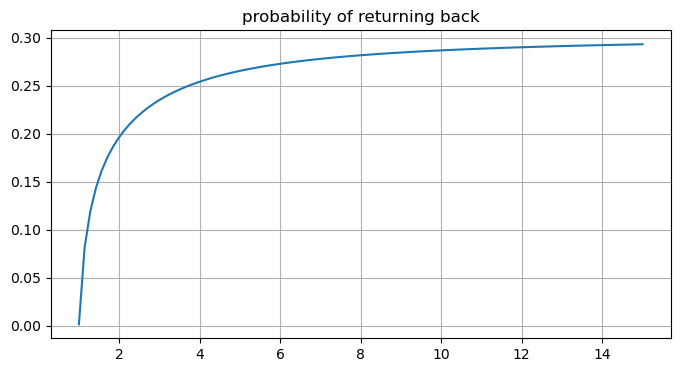

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 定義域
x = np.linspace(1.001, 15, 100)

# 関数定義
y = []
for a in x:
    y.append(Bridgeman_prob(a,13))

# グラフ描画
plt.figure(figsize=(8, 4))
plt.plot(x, y)
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.title("probability of returning back")
#plt.xlabel("x")
#plt.ylabel("f(x)")
plt.grid(True)
#plt.legend()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 定義域
x = np.linspace(120, 130, 10)

# 関数定義
y = []
for a in x:
    y.append(Bridgeman_prob(a,18))

# グラフ描画
plt.figure(figsize=(8, 4))
plt.plot(x, y)
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.title("probability of returning back")
#plt.xlabel("x")
#plt.ylabel("f(x)")
plt.grid(True)
#plt.legend()
plt.show()

NameError: name 'Bridgeman_prob' is not defined

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 定義域
x = np.linspace(100, 110, 10)

# 関数定義
y = []
for a in x:
    y.append(Bridgeman_prob(a,18))

# グラフ描画
plt.figure(figsize=(8, 4))
plt.plot(x, y)
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.title("probability of returning back")
#plt.xlabel("x")
#plt.ylabel("f(x)")
plt.grid(True)
#plt.legend()
plt.show()

NameError: name 'Bridgeman_prob' is not defined

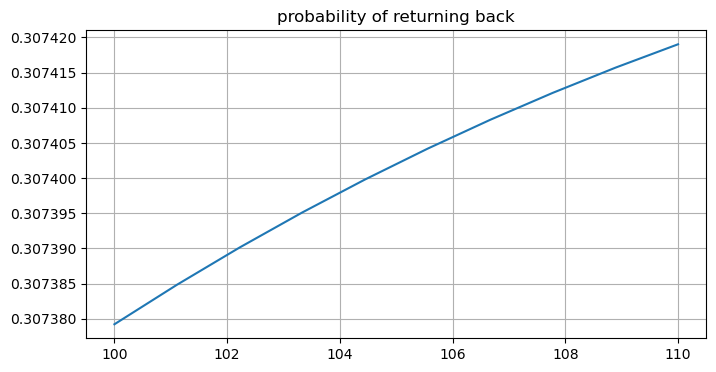

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 定義域
x = np.linspace(100, 110, 10)

# 関数定義
y = []
for a in x:
    y.append(Bridgeman_prob(a,17))

# グラフ描画
plt.figure(figsize=(8, 4))
plt.plot(x, y)
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.title("probability of returning back")
#plt.xlabel("x")
#plt.ylabel("f(x)")
plt.grid(True)
#plt.legend()
plt.show()

In [5]:
def make_xyz_list_tes(self,depth):
    n=depth
    result=["xy","xz"]
    if n <= 2:
        return result
    while len(result[-1])<n:
        newresult=[]
        for i in result:
            for char in "xyz":
                # 直前の文字と異なる場合にのみ追加
                if i[-1] != char:
                    newresult.append(i + char)
        result+=newresult
    return result

In [6]:
L = make_xyz_list_tes(1,4)
L

['xy',
 'xz',
 'xyx',
 'xyz',
 'xzx',
 'xzy',
 'xyx',
 'xyz',
 'xzx',
 'xzy',
 'xyxy',
 'xyxz',
 'xyzx',
 'xyzy',
 'xzxy',
 'xzxz',
 'xzyx',
 'xzyz']

In [23]:
L[-1][:-1]

'xzy'